In [45]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import special
import pandas as pd
from scipy.optimize import curve_fit


In [46]:
df = pd.read_csv('planks.csv')
df.head()
print(df.columns.tolist())
print(df.iloc[:,5:8].head())

['BLUE', 'Vin V ', 'Vout V', 'A (microAmps)', 'RED', 'Vin V .1', 'Vout V.1', 'A (microAmps).1', 'YELLOW', 'Vin V .2', 'Vout V.2', 'A (microAmps).2', 'GREEN', 'Vin V .3', 'Vout V.3', 'A (microAmps).3', 'WHITE', 'Vin V .4', 'Vout V.4', 'A (microAmps).4', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27']
   Vin V .1  Vout V.1  A (microAmps).1
0      0.00     0.003              0.0
1      0.50     0.499              0.0
2      1.00     0.997              0.1
3      1.40     1.393              0.3
4      1.42     1.414              0.5


In [47]:
#supposed to use voltage across diode!
blue = df.iloc[:, 1:4]
blue = blue.dropna()
blue = blue.sort_values(by= 'Vout V')
blue_copy = blue.copy()


red = df.iloc[:, 5:8]
red = red.dropna()
red = red.sort_values(by = 'Vout V.1')
red_copy = red.copy()


yellow = df.iloc[:, 9:12]
yellow = yellow.dropna()
yellow = yellow.drop([51,52,53,54])
yellow = yellow.sort_values(by = 'Vout V.2')
yellow_copy = yellow.copy()

green = df.iloc[:, 13:16]
green = green.dropna()
green = green.sort_values(by = 'Vout V.3')
green_copy = green.copy()

white = df.iloc[:, 17:20]
white = white.dropna()
white = white.sort_values(by = 'Vout V.4')
white_copy = white.copy()

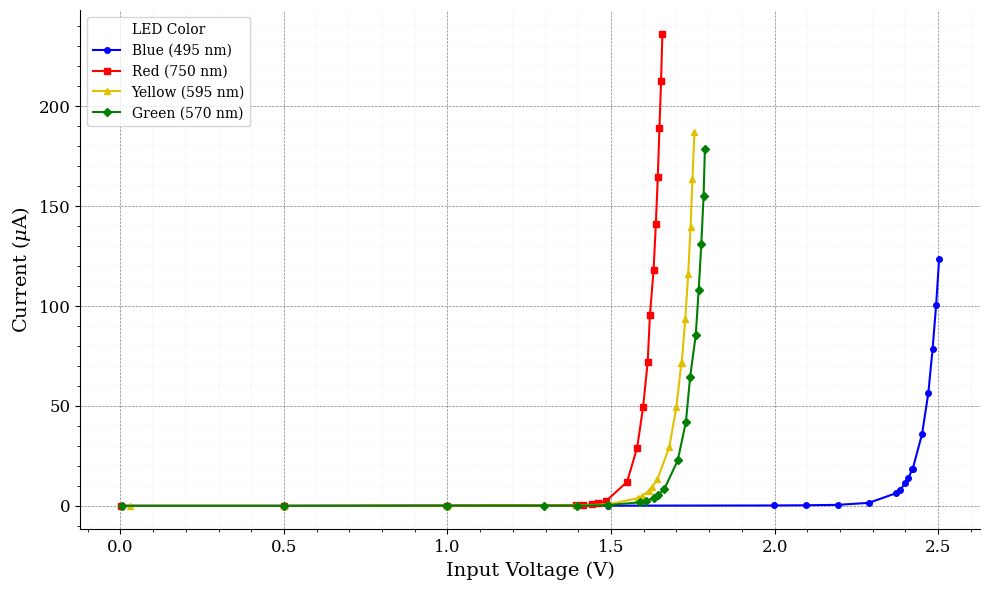

In [48]:
plt.figure(figsize=(10, 6))
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'DejaVu Serif'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

lam_blue = 495e-9   
lam_green = 570e-9 
lam_red = 750e-9    
lam_yellow = 595e-9

lam_blue_nm = 495
lam_green_nm = 570
lam_red_nm = 750  
lam_yellow_nm = 595

plt.plot(blue['Vout V'], blue['A (microAmps)'],
         label=f'Blue ({lam_blue_nm} nm)', color='blue',
         marker='o', markersize=4, linewidth=1.5)

plt.plot(red['Vout V.1'], red['A (microAmps).1'],
         label=f'Red ({lam_red_nm} nm)', color='red',
         marker='s', markersize=4, linewidth=1.5) # Different marker

plt.plot(yellow['Vout V.2'], yellow['A (microAmps).2'],
         label=f'Yellow ({lam_yellow_nm} nm)', color='#E0C000', # Darker yellow
         marker='^', markersize=4, linewidth=1.5) # Different marker

plt.plot(green['Vout V.3'], green['A (microAmps).3'],
         label=f'Green ({lam_green_nm} nm)', color='green',
         marker='D', markersize=4, linewidth=1.5) # Different marker

#plt.title('Current-Voltage (I-V) Characteristics of Various LEDs', fontsize=16)
plt.xlabel('Input Voltage (V)', fontsize=14)
plt.ylabel(r'Current ($\mu$A)', fontsize=14)

plt.legend(loc='upper left', fontsize=10, frameon=True, title='LED Color')
plt.grid(True, which='major', linestyle='--', linewidth=0.5, color='gray')
plt.grid(True, which='minor', linestyle=':', linewidth=0.3, color='lightgray')
plt.minorticks_on()
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
ax = plt.gca() # Get current axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('led_iv_characteristics.png', dpi=300)
plt.show()

In [49]:
# fitting 
def f(x, m, b):
    return m*x + b

# Create code function that compares R^2 for linear fitting. We want to make a piecewise linear model of the Diode IV

def compareLin(df, xlab,ylab, minPts=6):
    r2_scores = []
    fits = []

    for i in range(1, len(df)-minPts + 1):
        df_subset = df.iloc[i:len(df)]
        x=df_subset[xlab].values
        y=df_subset[ylab].values

        popt, _ = curve_fit(f, x, y)
        fits.append(popt)
    
        # Predicted values for subset
        y_pred = f(x, *popt)
    
        # Compute R^2
        ss_res = np.sum((y - y_pred)**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        r2 = 1 - (ss_res / ss_tot)
        r2_scores.append(r2)
    
    best_index = np.argmax(r2_scores)
    best_fit = fits[best_index]
    return best_fit, r2_scores[best_index]

In [50]:
# Get linear fit results and activation voltages

print(compareLin(blue, 'Vout V', 'A (microAmps)'))
print(compareLin(green, 'Vout V.3', 'A (microAmps).3'))
print(compareLin(red, 'Vout V.1', 'A (microAmps).1'))
print(compareLin(yellow, 'Vout V.2', 'A (microAmps).2'))

results_blue = compareLin(blue, 'Vout V', 'A (microAmps)')
results_green = compareLin(green, 'Vout V.3', 'A (microAmps).3')
results_red = compareLin(red, 'Vout V.1', 'A (microAmps).1')
results_yellow = compareLin(yellow, 'Vout V.2', 'A (microAmps).2')

Va_blue = -results_blue[0][1] / results_blue[0][0]    
Va_green = -results_green[0][1] / results_green[0][0]
Va_red = -results_red[0][1] / results_red[0][0]
Va_yellow = -results_yellow[0][1] / results_yellow[0][0]

print(f"Activation Voltage (Blue):   {Va_blue:.3f} V")
print(f"Activation Voltage (Green):  {Va_green:.3f} V")
print(f"Activation Voltage (Red):    {Va_red:.3f} V")
print(f"Activation Voltage (Yellow): {Va_yellow:.3f} V")


(array([ 1194.30106761, -2880.46108632]), 0.9362644460492638)
(array([ 2220.28556743, -3806.01500633]), 0.947551509338378)
(array([ 4382.78810028, -7031.3754956 ]), 0.9905039242136309)
(array([ 2969.96812916, -5032.33128578]), 0.9794626208108262)
Activation Voltage (Blue):   2.412 V
Activation Voltage (Green):  1.714 V
Activation Voltage (Red):    1.604 V
Activation Voltage (Yellow): 1.694 V


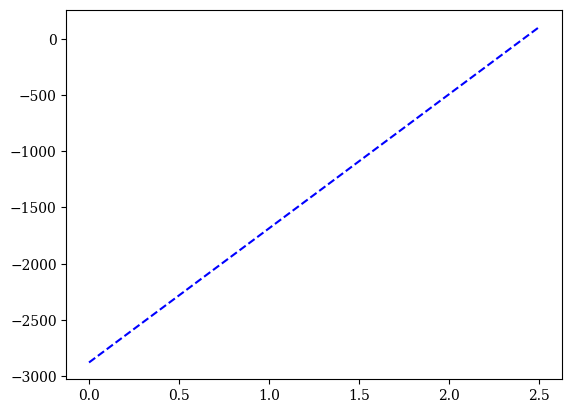

In [51]:
plt.plot(blue['Vout V'],f(blue['Vout V'], *results_blue[0]), color='blue', linestyle='--',)

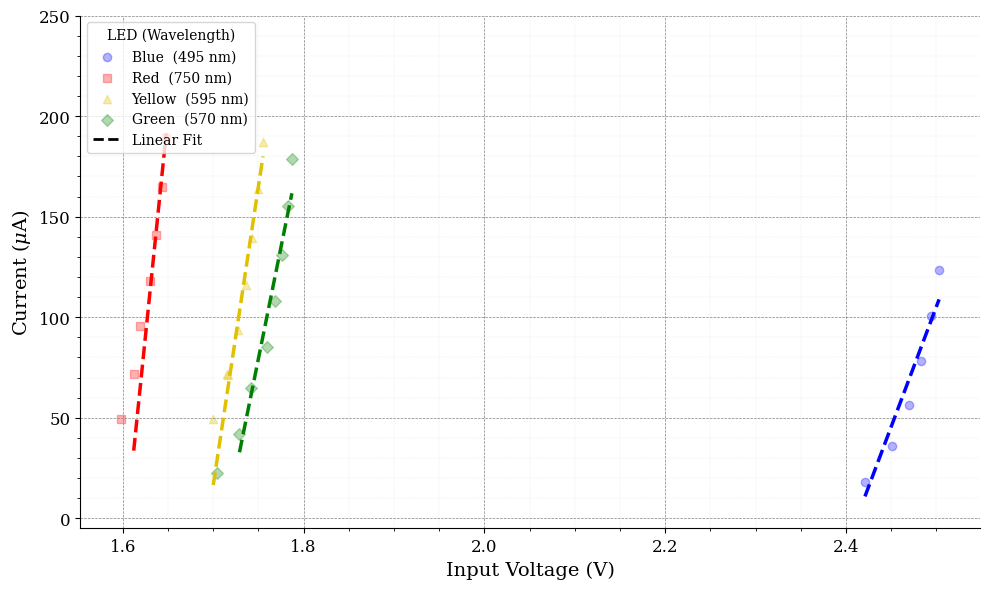

Min x-values: 2.421 1.598 1.7 1.704


In [ ]:
plt.figure(figsize=(10, 6))
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'DejaVu Serif'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

# Use semi-transparent markers so the fit line can be seen
plt.scatter(blue['Vout V'], blue['A (microAmps)'],
            label=f'Blue  ({lam_blue_nm} nm)', color='blue',
            marker='o', alpha=0.3)
plt.scatter(red['Vout V.1'], red['A (microAmps).1'],
            label=f'Red Data ({lam_red_nm} nm)', color='red',
            marker='s', alpha=0.3)
plt.scatter(yellow['Vout V.2'], yellow['A (microAmps).2'],
            label=f'Yellow Data ({lam_yellow_nm} nm)', color='#E0C000',
            marker='^', alpha=0.3)
plt.scatter(green['Vout V.3'], green['A (microAmps).3'],
            label=f'Green Data ({lam_green_nm} nm)', color='green',
            marker='D', alpha=0.3)

blue_line  = f(blue['Vout V'], *results_blue[0])
red_line   = f(red['Vout V.1'], *results_red[0])
yellow_line= f(yellow['Vout V.2'], *results_yellow[0])
green_line = f(green['Vout V.3'], *results_green[0])


plt.plot(blue['Vout V'][blue_line > 0] ,blue_line [blue_line > 0], color='blue', linestyle='--', linewidth=2.5)
plt.plot(red['Vout V.1'][red_line > 0],red_line [red_line > 0], color='red', linestyle='--', linewidth=2.5)
plt.plot(yellow['Vout V.2'][yellow_line > 0],yellow_line[yellow_line > 0], color='#E0C000', linestyle='--', linewidth=2.5)
plt.plot(green['Vout V.3'][green_line > 0], green_line[green_line > 0], color='green', linestyle='--', linewidth=2.5)


plt.plot([], [], color='black', linestyle='--', linewidth=2, label='Linear Fit')
#plt.title('Linear Regression of I-V Data to Find Activation Voltage', fontsize=16)
plt.xlabel('Input Voltage (V)', fontsize=14)
plt.ylabel(r'Current ($\mu$A)', fontsize=14)
plt.legend(loc='upper left', fontsize=10, frameon=True, title='LED (Wavelength)')
plt.grid(True, which='major', linestyle='--', linewidth=0.5, color='gray')
plt.grid(True, which='minor', linestyle=':', linewidth=0.3, color='lightgray')
plt.minorticks_on()
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(bottom=-5, top=250)  
   

ax = plt.gca() # Get current axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('technical_report_fit_plot.png', dpi=300)

plt.show()

print("Min x-values:",
      blue['Vout V'].min(),
      red['Vout V.1'].min(),
      yellow['Vout V.2'].min(),
      green['Vout V.3'].min())

In [53]:
lam_blue = 495e-9   
lam_green = 570e-9 
lam_red = 750e-9    
lam_yellow = 595e-9

lam_blue_nm = 495
lam_green_nm = 570
lam_red_nm = 750  
lam_yellow_nm = 595

lam_blue2 = 462.3e-9   
lam_green2 = 571e-9 
lam_red2 = 648.30e-9    
lam_yellow2 = 590e-9

#calculate h
e = 1.6022e-19  
c = 2.9979e8         


h_theo = 6.626e-34

h_blue = (e * Va_blue * lam_blue) / c
h_green = (e * Va_green * lam_green) / c
h_red = (e * Va_red * lam_red) / c
h_yellow = (e * Va_yellow * lam_yellow) / c

h_blue2 = (e * Va_blue * lam_blue2) / c
h_green2 = (e * Va_green * lam_green2) / c
h_red2 = (e * Va_red * lam_red2) / c
h_yellow2 = (e * Va_yellow * lam_yellow2) / c

print(h_blue)
print(h_blue2)
print(h_green)
print(h_green2)
print(h_red)
print(h_red2)
print(h_yellow)
print(h_yellow2)

6.380474482950956e-34
5.958976471652983e-34
5.221990787858571e-34
5.2311521752056915e-34
6.430587706966043e-34
5.558600013901447e-34
5.388079384446423e-34
5.342801406425864e-34


In [54]:
popt_blue, _ = curve_fit(f, blue['Vin V '], blue['A (microAmps)'])
popt_green, _ = curve_fit(f, green['Vin V .3'], green['A (microAmps).3'])
popt_red, _ = curve_fit(f, red['Vin V .1'], red['A (microAmps).1'])
popt_yellow, _ = curve_fit(f, yellow['Vin V .2'], yellow['A (microAmps).2'])

Va_blue = -popt_blue[1] / popt_blue[0]    
Va_green = -popt_green[1] / popt_green[0]
Va_red = -popt_red[1] / popt_red[0]
Va_yellow = -popt_yellow[1] / popt_yellow[0]

In [55]:
#remove all zero readings
blue = blue[blue['A (microAmps)'] > 1.5]
blue = blue.drop([8, 9, 10,11, 12])
green = green[green['A (microAmps).3'] > 1.5]
green = green.drop([6,7,8,9,10]) # removing outlier
red = red[red['A (microAmps).1'] > 1.5]
red = red.drop([7,8, 9,18, 17]) # removing outlier
yellow = yellow[yellow['A (microAmps).2'] > 1.5]
yellow = yellow.drop([5,6,7,8,9, 10]) # removing outlier



popt_blue, _ = curve_fit(f, blue['Vin V '], blue['A (microAmps)'])
popt_green, _ = curve_fit(f, green['Vin V .3'], green['A (microAmps).3'])
popt_red, _ = curve_fit(f, red['Vin V .1'], red['A (microAmps).1'])
popt_yellow, _ = curve_fit(f, yellow['Vin V .2'], yellow['A (microAmps).2'])

Va_blue = -popt_blue[1] / popt_blue[0]    
Va_green = -popt_green[1] / popt_green[0]
Va_red = -popt_red[1] / popt_red[0]
Va_yellow = -popt_yellow[1] / popt_yellow[0]

print(f"Activation Voltage (Blue):   {Va_blue} V")
print(f"Activation Voltage (Green):  {Va_green:.3f} V")
print(f"Activation Voltage (Red):    {Va_red:.3f} V")
print(f"Activation Voltage (Yellow): {Va_yellow:.3f} V")


Activation Voltage (Blue):   2.424964022395244 V
Activation Voltage (Green):  1.710 V
Activation Voltage (Red):    1.589 V
Activation Voltage (Yellow): 1.689 V


In [56]:
V_activation = [Va_blue, Va_green, Va_red, Va_yellow]
V_activation

[2.424964022395244, 1.7095511901180735, 1.5894704434457498, 1.6886734979025348]

[2.424964022395244, 1.7095511901180735, 1.5894704434457498, 1.6886734979025348]


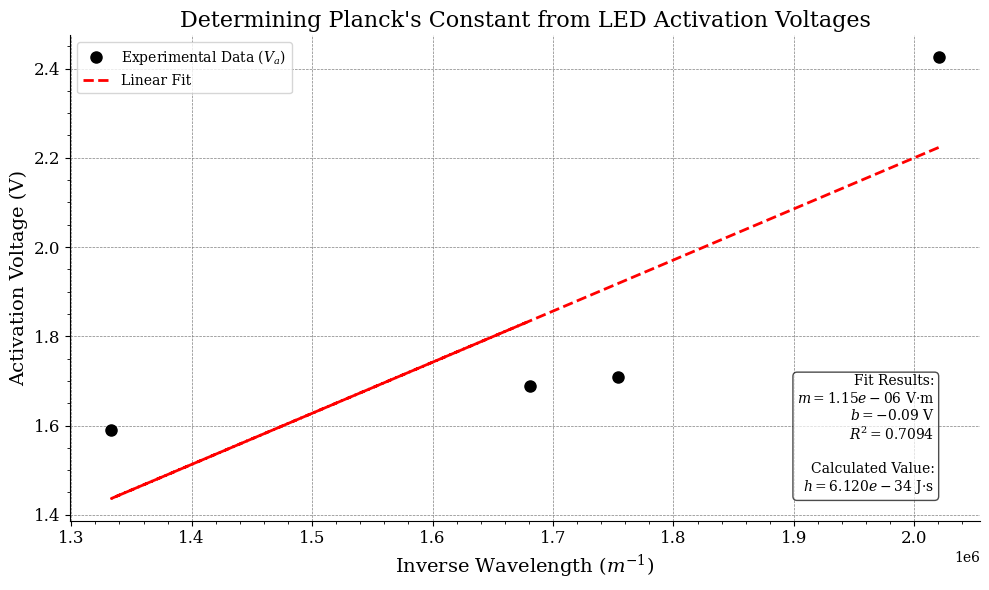

In [57]:
V_activation = [Va_blue, Va_green, Va_red, Va_yellow]
wavelengths = np.array([lam_blue, lam_green, lam_red, lam_yellow])
inverse_wavelengths = 1 / wavelengths
print(V_activation)
#join the data into one table
combined_df = pd.DataFrame({
    'Inverse Wavelength (m)': inverse_wavelengths,
    'Activation Voltage (V)': V_activation,
})

popt_comb, _ = curve_fit(f, combined_df['Inverse Wavelength (m)'], combined_df['Activation Voltage (V)'])
m_slope = popt_comb[0]
b_intercept = popt_comb[1]

h = (m_slope*e)/c
err = abs((h - h_theo) / h_theo) * 100

y_actual = combined_df['Activation Voltage (V)']
y_predicted = f(combined_df['Inverse Wavelength (m)'], m_slope, b_intercept)
residuals = y_actual - y_predicted
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y_actual - np.mean(y_actual))**2)
r_squared = 1 - (ss_res / ss_tot)

plt.figure(figsize=(10, 6))


plt.plot(combined_df['Inverse Wavelength (m)'], 
         combined_df['Activation Voltage (V)'],
         marker='o', markersize=8, linestyle='None', 
         color='black', label='Experimental Data ($V_a$)')
plt.plot(combined_df['Inverse Wavelength (m)'], y_predicted,
         color='red', linestyle='--', linewidth=2, 
         label='Linear Fit')


plt.title("Determining Planck's Constant from LED Activation Voltages", fontsize=16)
plt.xlabel(r'Inverse Wavelength ($m^{-1}$)', fontsize=14)
plt.ylabel('Activation Voltage (V)', fontsize=14)
plt.legend(loc='upper left', fontsize=10, frameon=True)

plt.grid(True, which='major', linestyle='--', linewidth=0.5, color='gray')
plt.minorticks_on()
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))


text_str = (
    f"Fit Results:\n"
    f"$m = {m_slope:.2e}$ V·m\n"
    f"$b = {b_intercept:.2f}$ V\n"
    f"$R^2 = {r_squared:.4f}$\n\n"
    f"Calculated Value:\n"
    f"$h = {h:.3e}$ J·s"
)

props = dict(boxstyle='round', facecolor='white', alpha=0.7)
ax.text(0.95, 0.05, text_str, transform=ax.transAxes, fontsize=10,
        verticalalignment='bottom', horizontalalignment='right', bbox=props)

plt.tight_layout()
plt.savefig('technical_report_final_fit.png')
plt.show()

In [58]:
blue

,Vin V,Vout V,A (microAmps)
13,2.5,2.421,18.3
14,2.6,2.451,36.0
15,2.7,2.470,56.4
16,2.8,2.483,78.3
17,2.9,2.494,100.6
18,3.0,2.503,123.4


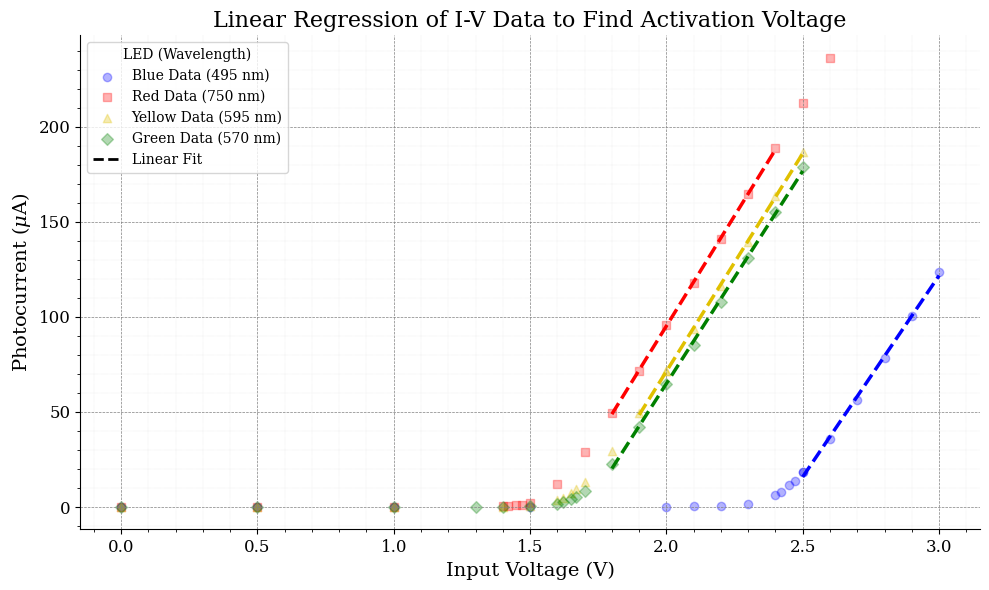

In [59]:
plt.figure(figsize=(10, 6))
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'DejaVu Serif'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

# Use semi-transparent markers so the fit line can be seen
plt.scatter(blue_copy['Vin V '], blue_copy['A (microAmps)'],
            label=f'Blue Data ({lam_blue_nm} nm)', color='blue',
            marker='o', alpha=0.3)
plt.scatter(red_copy['Vin V .1'], red_copy['A (microAmps).1'],
            label=f'Red Data ({lam_red_nm} nm)', color='red',
            marker='s', alpha=0.3)
plt.scatter(yellow_copy['Vin V .2'], yellow_copy['A (microAmps).2'],
            label=f'Yellow Data ({lam_yellow_nm} nm)', color='#E0C000',
            marker='^', alpha=0.3)
plt.scatter(green_copy['Vin V .3'], green_copy['A (microAmps).3'],
            label=f'Green Data ({lam_green_nm} nm)', color='green',
            marker='D', alpha=0.3)


plt.plot(blue['Vin V '], f(blue['Vin V '], *popt_blue),
         color='blue', linestyle='--', linewidth=2.5)
plt.plot(red['Vin V .1'], f(red['Vin V .1'], *popt_red),
         color='red', linestyle='--', linewidth=2.5)
plt.plot(yellow['Vin V .2'], f(yellow['Vin V .2'], *popt_yellow),
         color='#E0C000', linestyle='--', linewidth=2.5)
plt.plot(green['Vin V .3'], f(green['Vin V .3'], *popt_green),
         color='green', linestyle='--', linewidth=2.5)


plt.plot([], [], color='black', linestyle='--', linewidth=2, label='Linear Fit')
plt.title('Linear Regression of I-V Data to Find Activation Voltage', fontsize=16)
plt.xlabel('Input Voltage (V)', fontsize=14)
plt.ylabel(r'Photocurrent ($\mu$A)', fontsize=14)
plt.legend(loc='upper left', fontsize=10, frameon=True, title='LED (Wavelength)')
plt.grid(True, which='major', linestyle='--', linewidth=0.5, color='gray')
plt.grid(True, which='minor', linestyle=':', linewidth=0.3, color='lightgray')
plt.minorticks_on()
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

ax = plt.gca() # Get current axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('technical_report_fit_plot.png', dpi=300)
plt.show()



In [60]:
#calculate h
e = 1.6022e-19  
c = 2.9979e8         


h_theo = 6.626e-34

h_blue = (e * Va_blue * lam_blue) / c
h_green = (e * Va_green * lam_green) / c
h_red = (e * Va_red * lam_red) / c
h_yellow = (e * Va_yellow * lam_yellow) / c

#error calculation
error_blue = abs((h_blue - h_theo) / h_theo) * 100
error_green = abs((h_green - h_theo) / h_theo) * 100
error_red = abs((h_red - h_theo) / h_theo) * 100
error_yellow = abs((h_yellow - h_theo) / h_theo) * 100

print(f"Calculated Planck's constant (Blue):   {h_blue:.3e} J·s, Error: {error_blue:.2f}%")
print(f"Calculated Planck's constant (Green):  {h_green:.3e} J·s, Error: {error_green:.2f}%")
print(f"Calculated Planck's constant (Red):    {h_red:.3e} J·s, Error: {error_red:.2f}%")
print(f"Calculated Planck's constant (Yellow): {h_yellow:.3e} J·s, Error: {error_yellow:.2f}%")

Calculated Planck's constant (Blue):   6.415e-34 J·s, Error: 3.18%
Calculated Planck's constant (Green):  5.208e-34 J·s, Error: 21.40%
Calculated Planck's constant (Red):    6.371e-34 J·s, Error: 3.85%
Calculated Planck's constant (Yellow): 5.370e-34 J·s, Error: 18.96%


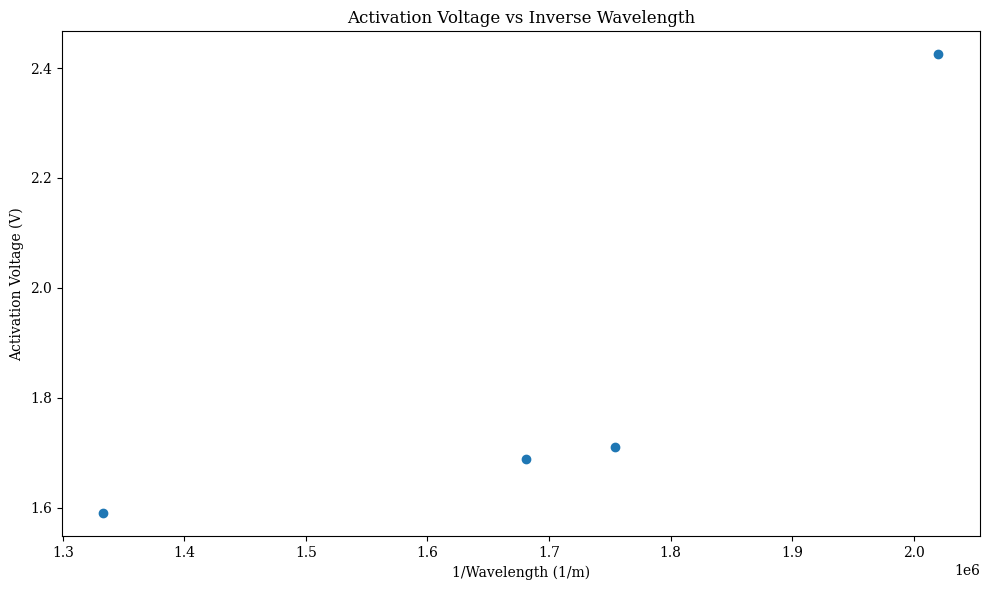

In [61]:
V_activation = [Va_blue, Va_green, Va_red, Va_yellow]
wavelengths = np.array([lam_blue, lam_green, lam_red, lam_yellow])
inverse_wavelengths = 1 / wavelengths

plt.figure(figsize =(10,6))
plt.plot(1/wavelengths, V_activation, marker='o', linestyle='None')
plt.xlabel('1/Wavelength (1/m)')
plt.ylabel('Activation Voltage (V)')
plt.title('Activation Voltage vs Inverse Wavelength')
plt.tight_layout()
plt.show()

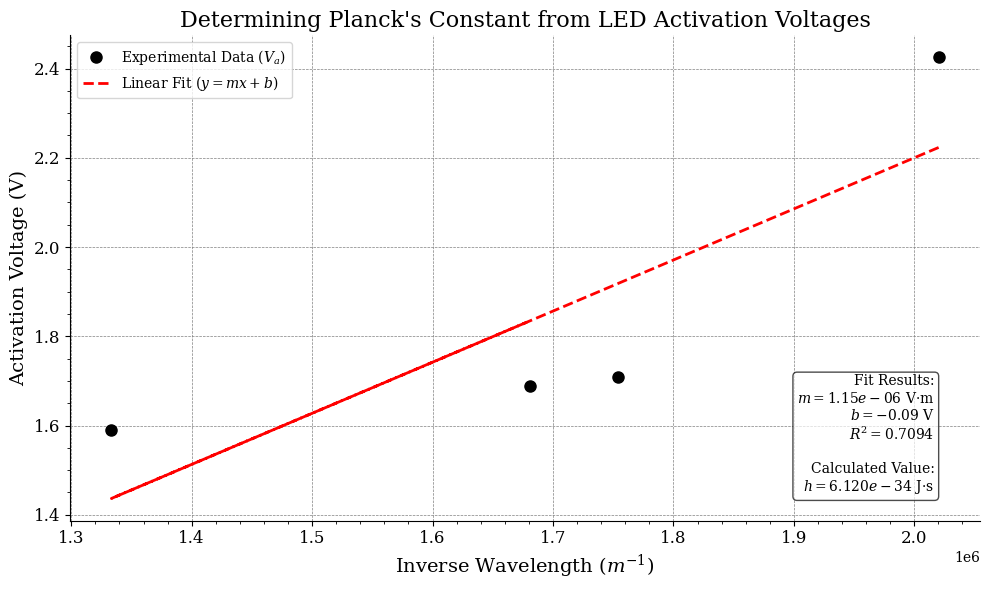

In [62]:
#join the data into one table
combined_df = pd.DataFrame({
    'Inverse Wavelength (m)': inverse_wavelengths,
    'Activation Voltage (V)': V_activation,
})

popt_comb, _ = curve_fit(f, combined_df['Inverse Wavelength (m)'], combined_df['Activation Voltage (V)'])
m_slope = popt_comb[0]
b_intercept = popt_comb[1]

h = (m_slope*e)/c
err = abs((h - h_theo) / h_theo) * 100

y_actual = combined_df['Activation Voltage (V)']
y_predicted = f(combined_df['Inverse Wavelength (m)'], m_slope, b_intercept)
residuals = y_actual - y_predicted
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y_actual - np.mean(y_actual))**2)
r_squared = 1 - (ss_res / ss_tot)

plt.figure(figsize=(10, 6))


plt.plot(combined_df['Inverse Wavelength (m)'], 
         combined_df['Activation Voltage (V)'],
         marker='o', markersize=8, linestyle='None', 
         color='black', label='Experimental Data ($V_a$)')
plt.plot(combined_df['Inverse Wavelength (m)'], y_predicted,
         color='red', linestyle='--', linewidth=2, 
         label='Linear Fit ($y = mx + b$)')


plt.title("Determining Planck's Constant from LED Activation Voltages", fontsize=16)
plt.xlabel(r'Inverse Wavelength ($m^{-1}$)', fontsize=14)
plt.ylabel('Activation Voltage (V)', fontsize=14)
plt.legend(loc='upper left', fontsize=10, frameon=True)

plt.grid(True, which='major', linestyle='--', linewidth=0.5, color='gray')
plt.minorticks_on()
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))


text_str = (
    f"Fit Results:\n"
    f"$m = {m_slope:.2e}$ V·m\n"
    f"$b = {b_intercept:.2f}$ V\n"
    f"$R^2 = {r_squared:.4f}$\n\n"
    f"Calculated Value:\n"
    f"$h = {h:.3e}$ J·s"
)

props = dict(boxstyle='round', facecolor='white', alpha=0.7)
ax.text(0.95, 0.05, text_str, transform=ax.transAxes, fontsize=10,
        verticalalignment='bottom', horizontalalignment='right', bbox=props)

plt.tight_layout()
plt.savefig('technical_report_final_fit.png')
plt.show()




In [63]:

print(f"Calculated Planck's constant (Combined): {h:.3e} J·s, Error: {err:.2f}%")

Calculated Planck's constant (Combined): 6.120e-34 J·s, Error: 7.63%
